In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

X = np.random.uniform(-1, 1, (1000, 3))
y = (np.linalg.norm(X, axis=1) > 0.7).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)




I0000 00:00:1774696189.568163   13237 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774696189.571850   13237 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774696189.930592   13237 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774696191.860068   13237 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [ ]:
model = models.Sequential([
    layers.Dense(32, activation='relu', input_shape=(3,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

/home/main/Documents/School/NOD/NOD/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1774696193.752770   13237 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [5]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy', # Zmiana na binary_crossentropy dla 1 wyjścia
    metrics=['accuracy']
)

model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), verbose=1)

loss, accuracy = model.evaluate(X_test, y_test)
print(f'\nAccuracy:{accuracy:.4f}')


Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8462 - loss: 0.2505 - val_accuracy: 0.8550 - val_loss: 0.2555
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8562 - loss: 0.2409 - val_accuracy: 0.8600 - val_loss: 0.2473
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8650 - loss: 0.2326 - val_accuracy: 0.8800 - val_loss: 0.2400
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8737 - loss: 0.2242 - val_accuracy: 0.8850 - val_loss: 0.2329
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8800 - loss: 0.2170 - val_accuracy: 0.8900 - val_loss: 0.2258
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8825 - loss: 0.2089 - val_accuracy: 0.8950 - val_loss: 0.2179
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9025 - loss: 0.2013 - val_accuracy: 0.9000 - val_loss: 0.2101
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9087 - loss: 0.1929 - val_accuracy: 0.9100 - val_loss

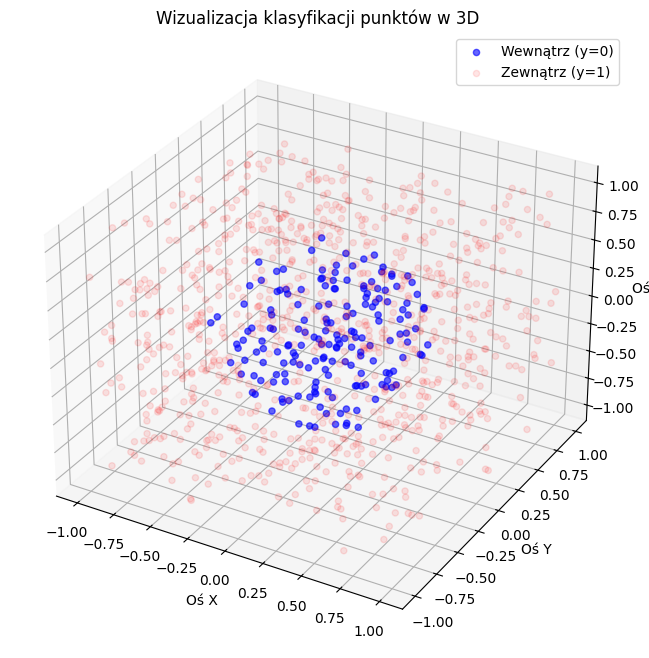

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

X = np.random.uniform(-1, 1, (1000, 3))
y = (np.linalg.norm(X, axis=1) > 0.7).astype(int)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

inside = X[y == 0]
outside = X[y == 1]

ax.scatter(inside[:, 0], inside[:, 1], inside[:, 2], c='blue', label='Wewnątrz (y=0)', alpha=0.6)
ax.scatter(outside[:, 0], outside[:, 1], outside[:, 2], c='red', label='Zewnątrz (y=1)', alpha=0.1)

ax.set_title('Wizualizacja klasyfikacji punktów w 3D')
ax.set_xlabel('Oś X')
ax.set_ylabel('Oś Y')
ax.set_zlabel('Oś Z')
ax.legend()

plt.show()